# Exercise 10 — Boston Housing Data Set

This exercise explores the Boston housing dataset from the ISLP library. The goal is to perform an exploratory data analysis (EDA): understanding the structure of the data, identifying relationships between predictors, and highlighting notable patterns in crime rates, tax rates, and housing values across Boston suburbs.

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 
from ISLP import load_data

In [10]:
boston = load_data("Boston")
print(boston.shape)
print(boston.columns)
print(boston.isnull().sum())


(506, 13)
Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
lstat      0
medv       0
dtype: int64


In [50]:
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


* crim — crime rate per person
* zn — % of land zoned for large residential lots
* indus — % of land used for non-retail business
* chas — 1 if the suburb is next to the Charles River, 0 otherwise
* nox — air pollution level (nitric oxide)
* rm — average number of rooms per home
* age — % of homes built before 1940
* dis — distance to major employment centers
* rad — how easy it is to access highways
* tax — property tax rate
* ptratio — number of students per teacher
* lstat — % of population considered lower income
* medv — median home value (in $1,000s)

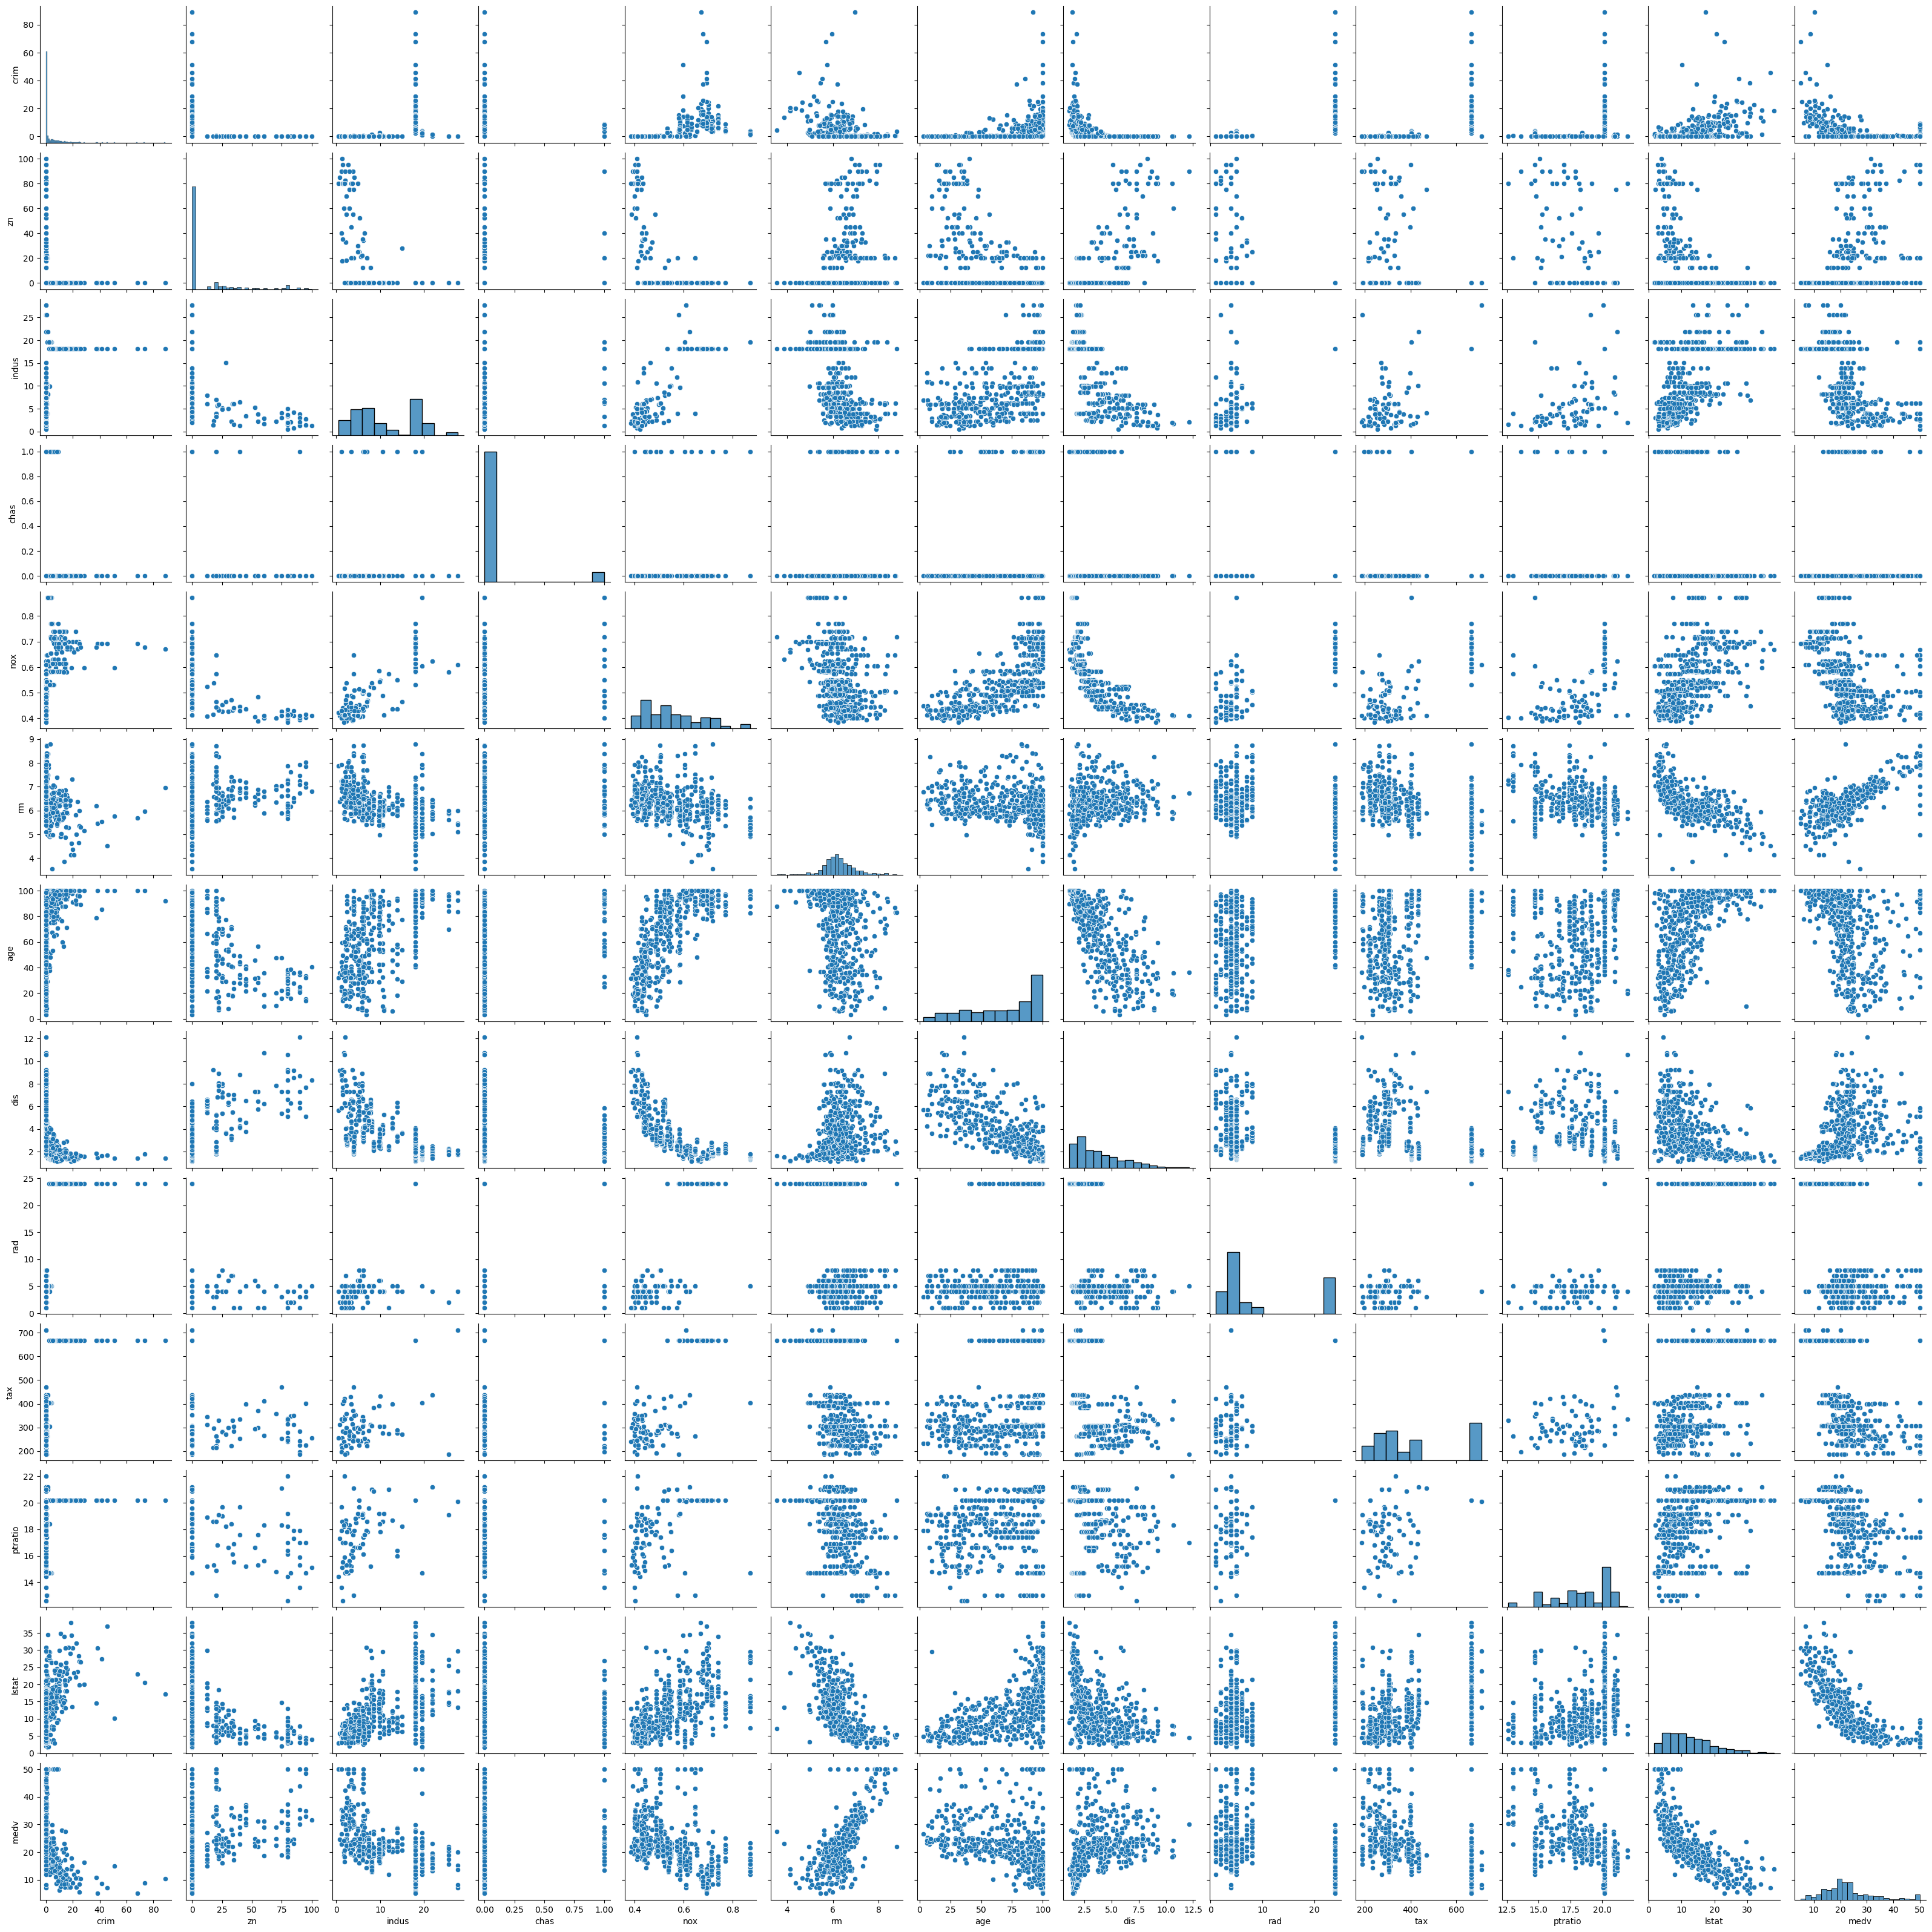

In [9]:
sns.pairplot(boston)

From a first broad analysis it is clear that lots of the variables seam to show non-linear correlation.

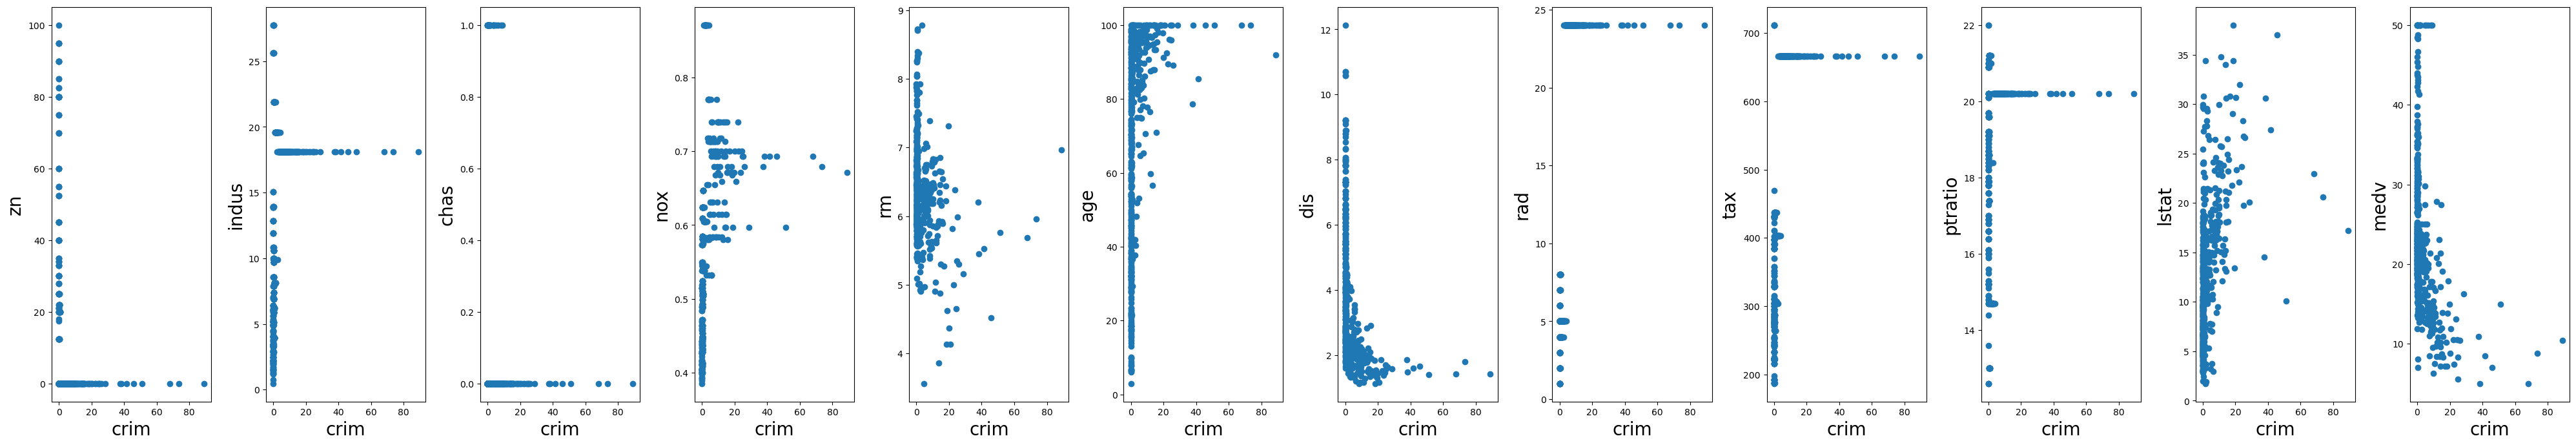

In [28]:
fig, axes = plt.subplots(1,len(boston.columns)-1, figsize = (40,7))
predictors = [col for col in boston.columns if col != 'crim']
for i,col in enumerate(predictors):
    axes[i].scatter(boston['crim'],boston[col])
    axes[i].set_ylabel(col,fontsize=20)
    axes[i].set_xlabel('crim',fontsize=20)


plt.tight_layout()
plt.show()

In [46]:
boston[(boston["rad"] == 24) & (boston["tax"] == 666) & (boston["indus"] > 17) & (boston["ptratio"] > 19) & (boston["zn"] == 0) & (boston["chas"] == 0)].shape

(124, 13)

Several variable like "zn","indus","chas","rad","tax" and "pration" seam are most likely tagging the same subset (~26% of the data). The actual variation in crime is better explained by continuous variables like lstat, medv, dis, age, and nox — all related to socioeconomic status and urban density. These carry the real predictive power.

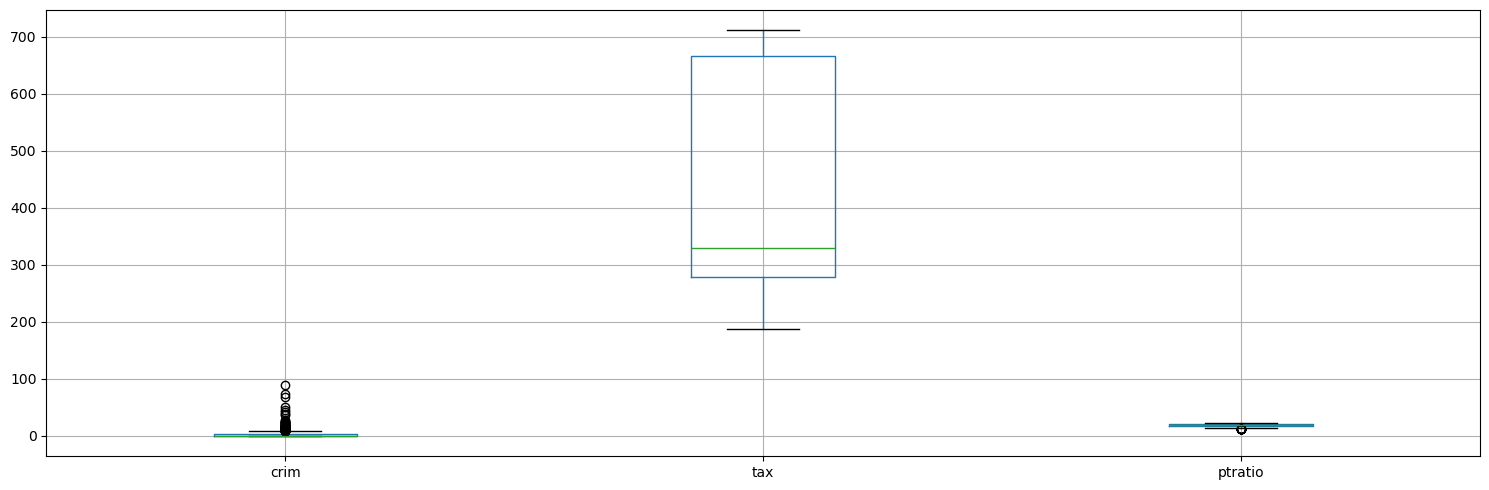

In [48]:
boston[["crim","tax","ptratio"]].boxplot(figsize=(15,5))
plt.tight_layout()
plt.show()

In [49]:
boston[['crim','tax','ptratio']].describe()

,crim,tax,ptratio
count,506.000000,506.000000,506.000000
mean,3.613524,408.237154,18.455534
std,8.601545,168.537116,2.164946
min,0.006320,187.000000,12.600000
25%,0.082045,279.000000,17.400000
50%,0.256510,330.000000,19.050000
75%,3.677083,666.000000,20.200000
max,88.976200,711.000000,22.000000


* Crime rate has a very narrow interquartile range near zero (75th percentile = 3.68), but extreme outliers reaching 88.97. The vast majority of suburbs have low crime; the high values are driven by a small number of extreme suburbs.
* Tax rate has a wide interquartile range, but this is misleading — the distribution is bimodal. About 25% of suburbs cluster tightly around 666, with only a few reaching 711. This isn't a gradual spread but a specific group of suburbs sharing nearly identical high tax rates.
* Pupil-teacher ratio is compact: most values fall between 17 and 21, with a standard deviation of only 2.16

In [61]:
print(boston[boston["chas"] == 1].shape[0])
print(boston["ptratio"].median())

35
19.05


In [67]:
boston["medv"].idxmin()
boston.iloc[boston["medv"].idxmin()] / boston.max()

crim       0.431034
zn         0.000000
indus      0.652487
chas       0.000000
nox        0.795637
rm         0.621071
age        1.000000
dis        0.122838
rad        1.000000
tax        0.936709
ptratio    0.918182
lstat      0.805636
medv       0.100000
dtype: float64

So this suburb has the oldest housing, highest highway access, highest tax, most pollution, highest proportion of lower-income population, and is closest to employment centers — while having the cheapest homes and no residential zoning.
It's not just a suburb with low home values — it's extreme on nearly every dimension simultaneously.

In [80]:
print(boston[boston["rm"]>7].shape[0])
print(boston[boston["rm"]>8].shape[0])

boston[boston["rm"]>8].mean() / boston.mean()

64
13


crim       0.198918
zn         1.198154
indus      0.635593
chas       2.224176
nox        0.972135
rm         1.328405
age        1.043216
dis        0.903861
rad        0.781361
tax        0.796294
ptratio    0.886538
lstat      0.340629
medv       1.961584
dtype: float64

Suburbs with an average "rm" > 8 have higher values compared with the average of the dataset for the positive predictors and lower values for negative predictors. These suburbs are full of wealthy houses. 